In [15]:
#Importación de librerías correspondientes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [17]:
#Carga de datos
base_path = r"C:\Users\Nefi\OneDrive\Documentos\09-EBAC\Python\Referencia\Proyecto"
file_path = os.path.join(base_path, "sales_consolidado.csv")

df = pd.read_csv(file_path)

In [18]:
#Calidad de datos
print("\nPorcentaje de nulos en columnas clave:")
for col in ["BRAND", "MANUFACTURER", "FORMAT"]:
    if col in df.columns:
        print(f"{col}: {round(df[col].isna().mean()*100,2)} %")


Porcentaje de nulos en columnas clave:
BRAND: 92.46 %
MANUFACTURER: 92.46 %
FORMAT: 92.46 %


In [27]:
#Identificación de variables clave
variables_clave = {
    "Ventas Monetarias": "TOTAL_VALUE_SALES",
    "Ventas en Unidades": "TOTAL_UNIT_SALES",
    "Promedio Semanal": "TOTAL_UNIT_AVG_WEEKLY_SALES",
    "Dimensión Temporal": ["DATE", "YEAR", "MONTH"],
    "Dimensión Geográfica": "REGION"
}

print("\nVariables clave identificadas:")
display(pd.DataFrame(variables_clave.items(), columns=["Tipo", "Variable"]))


Variables clave identificadas:


,Tipo,Variable
0,Ventas Monetarias,TOTAL_VALUE_SALES
1,Ventas en Unidades,TOTAL_UNIT_SALES
2,Promedio Semanal,TOTAL_UNIT_AVG_WEEKLY_SALES
3,Dimensión Temporal,"[DATE, YEAR, MONTH]"
4,Dimensión Geográfica,REGION


In [28]:
#Definición de variables numéricas
numeric_cols = [
    "TOTAL_UNIT_SALES",
    "TOTAL_VALUE_SALES",
    "TOTAL_UNIT_AVG_WEEKLY_SALES"
]
display(df[numeric_cols].describe())

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
count,122002.000000,122002.000000,122002.000000
mean,3.211097,90.513761,10.099904
std,14.496009,350.236505,22.650142
min,0.000000,0.001000,0.042000
25%,0.063000,2.662000,2.316000
50%,0.367000,16.812000,3.993500
75%,1.520000,62.961500,8.898000
max,504.681000,12236.759000,794.000000


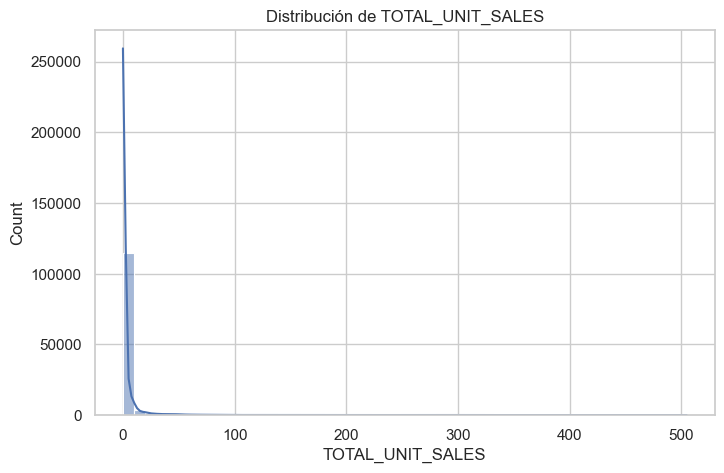

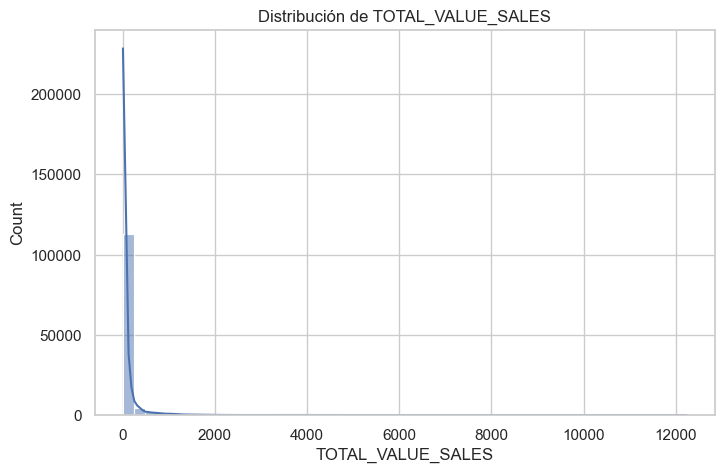

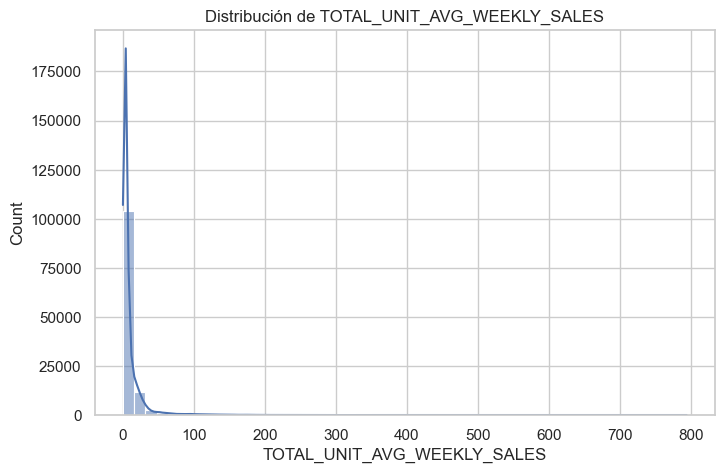

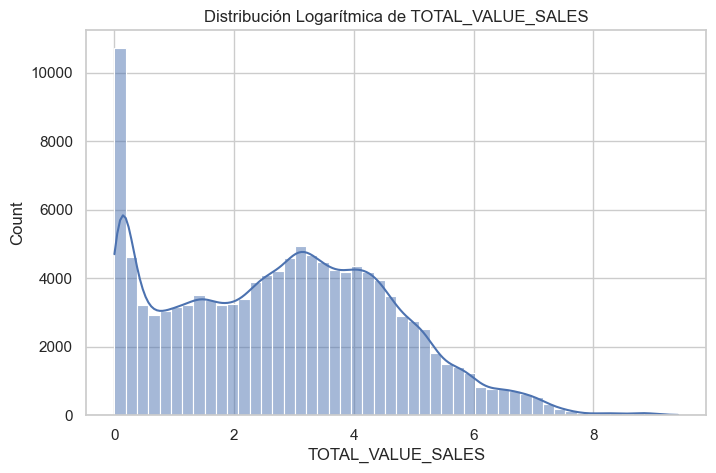

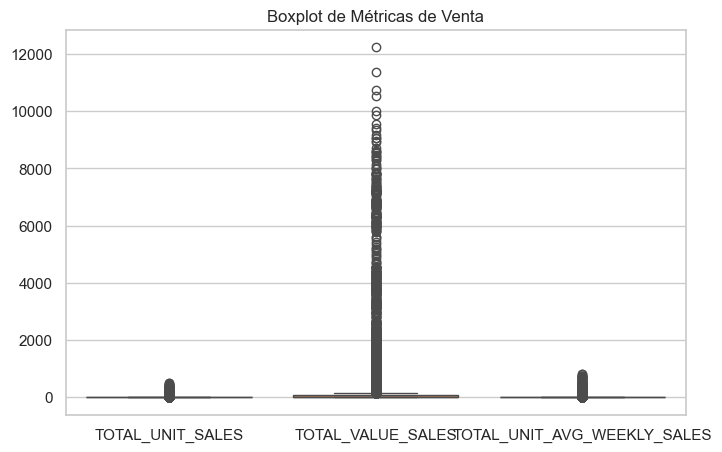

In [29]:
#Distribución de ventas
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

# Transformación logarítmica (mejor para datos sesgados)
plt.figure()
sns.histplot(np.log1p(df["TOTAL_VALUE_SALES"]), bins=50, kde=True)
plt.title("Distribución Logarítmica de TOTAL_VALUE_SALES")
plt.show()

# Boxplot general
plt.figure()
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot de Métricas de Venta")
plt.show()

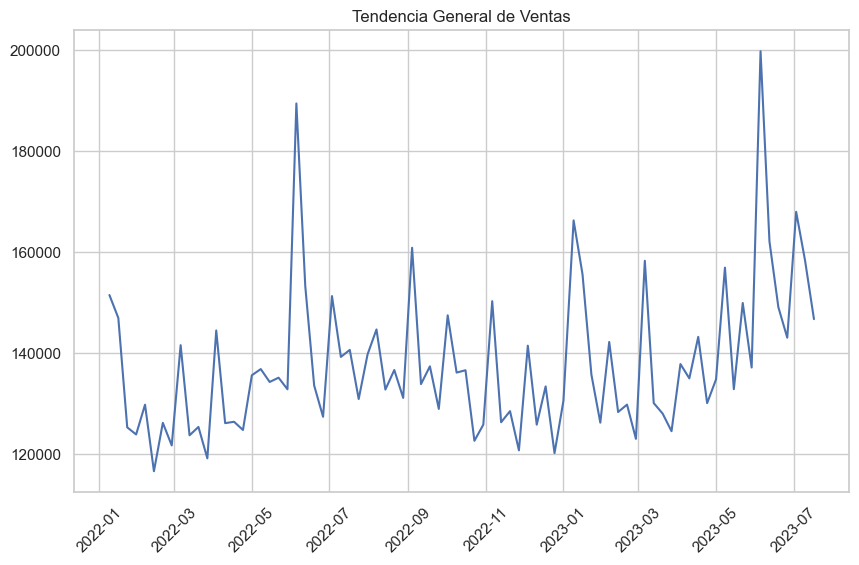

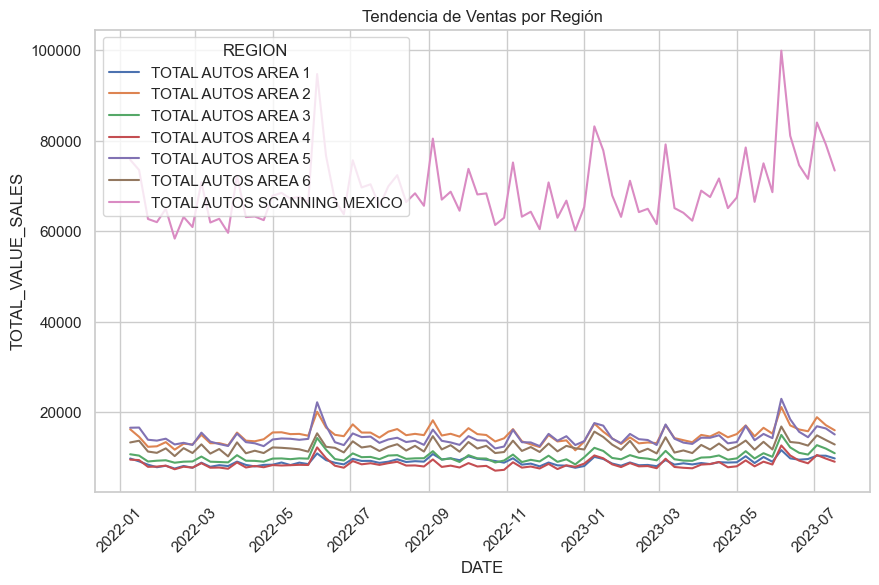

In [30]:
#Tendencia en el tiempo
if "DATE" in df.columns:

    ventas_tiempo = df.groupby("DATE")["TOTAL_VALUE_SALES"].sum().reset_index()

    plt.figure(figsize=(10,6))
    plt.plot(ventas_tiempo["DATE"], ventas_tiempo["TOTAL_VALUE_SALES"])
    plt.title("Tendencia General de Ventas")
    plt.xticks(rotation=45)
    plt.show()

    # Tendencia por región
    ventas_region_tiempo = (
        df.groupby(["DATE","REGION"])["TOTAL_VALUE_SALES"]
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(10,6))
    sns.lineplot(
        data=ventas_region_tiempo,
        x="DATE",
        y="TOTAL_VALUE_SALES",
        hue="REGION"
    )
    plt.title("Tendencia de Ventas por Región")
    plt.xticks(rotation=45)
    plt.show()

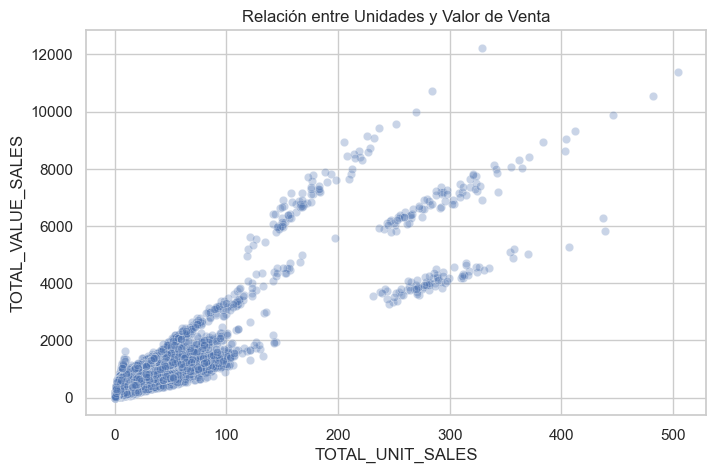

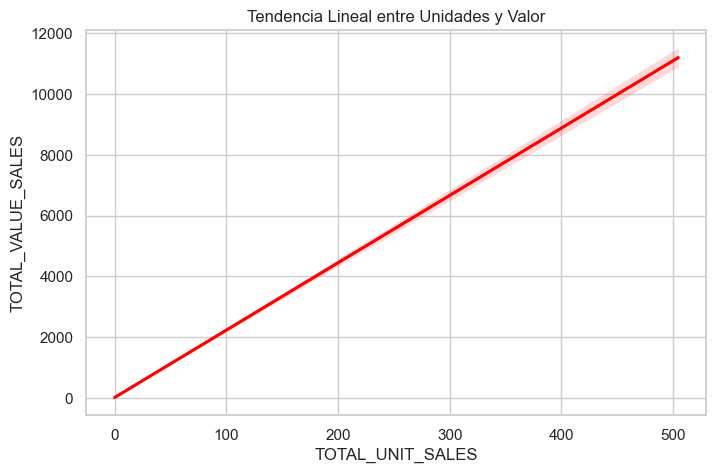


Matriz de correlación:


,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
TOTAL_UNIT_SALES,1.000000,0.916252,0.426035
TOTAL_VALUE_SALES,0.916252,1.000000,0.367367
TOTAL_UNIT_AVG_WEEKLY_SALES,0.426035,0.367367,1.000000


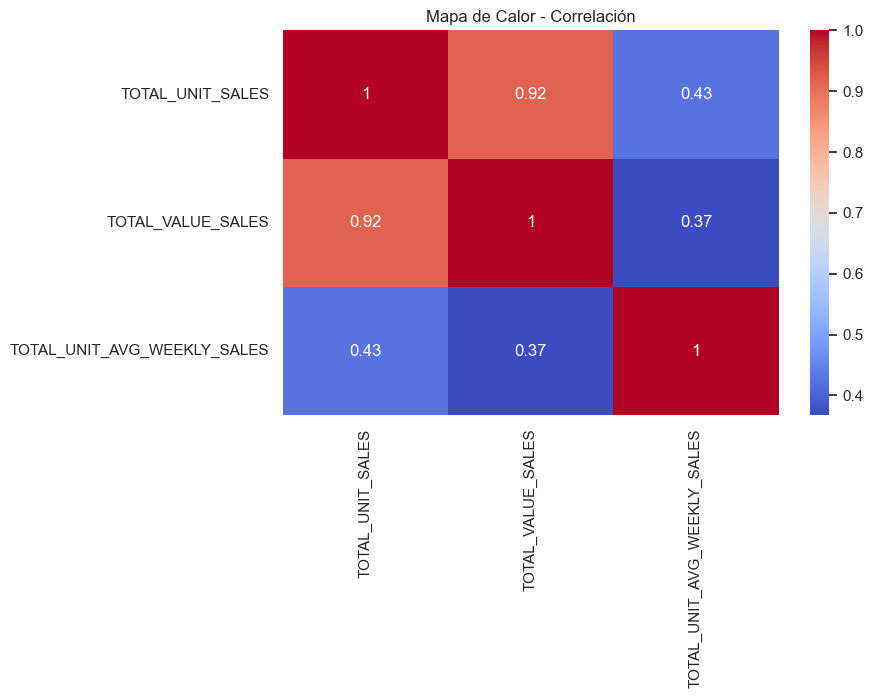

In [31]:
#Relación entre variables
plt.figure()
sns.scatterplot(
    data=df,
    x="TOTAL_UNIT_SALES",
    y="TOTAL_VALUE_SALES",
    alpha=0.3
)
plt.title("Relación entre Unidades y Valor de Venta")
plt.show()

# Regresión
sns.regplot(
    data=df,
    x="TOTAL_UNIT_SALES",
    y="TOTAL_VALUE_SALES",
    scatter=False,
    color="red"
)
plt.title("Tendencia Lineal entre Unidades y Valor")
plt.show()

# Correlación numérica
corr = df[numeric_cols].corr()
print("\nMatriz de correlación:")
display(corr)

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mapa de Calor - Correlación")
plt.show()

REGION
TOTAL AUTOS SCANNING MEXICO    5521429.320
TOTAL AUTOS AREA 2             1188796.150
TOTAL AUTOS AREA 5             1153335.538
TOTAL AUTOS AREA 6              983957.571
TOTAL AUTOS AREA 3              803655.337
TOTAL AUTOS AREA 1              714249.979
TOTAL AUTOS AREA 4              677435.998
Name: TOTAL_VALUE_SALES, dtype: float64

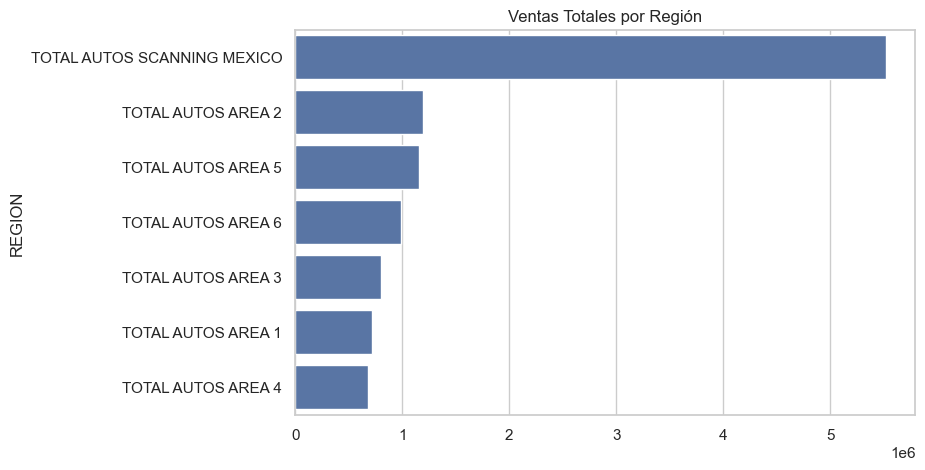

YEAR,2022,2023
REGION,,
TOTAL AUTOS AREA 1,457219.712,257030.267
TOTAL AUTOS AREA 2,756645.652,432150.498
TOTAL AUTOS AREA 3,506531.266,297124.071
TOTAL AUTOS AREA 4,429796.483,247639.515
TOTAL AUTOS AREA 5,729042.255,424293.283
TOTAL AUTOS AREA 6,625074.617,358882.954
TOTAL AUTOS SCANNING MEXICO,3504309.066,2017120.254


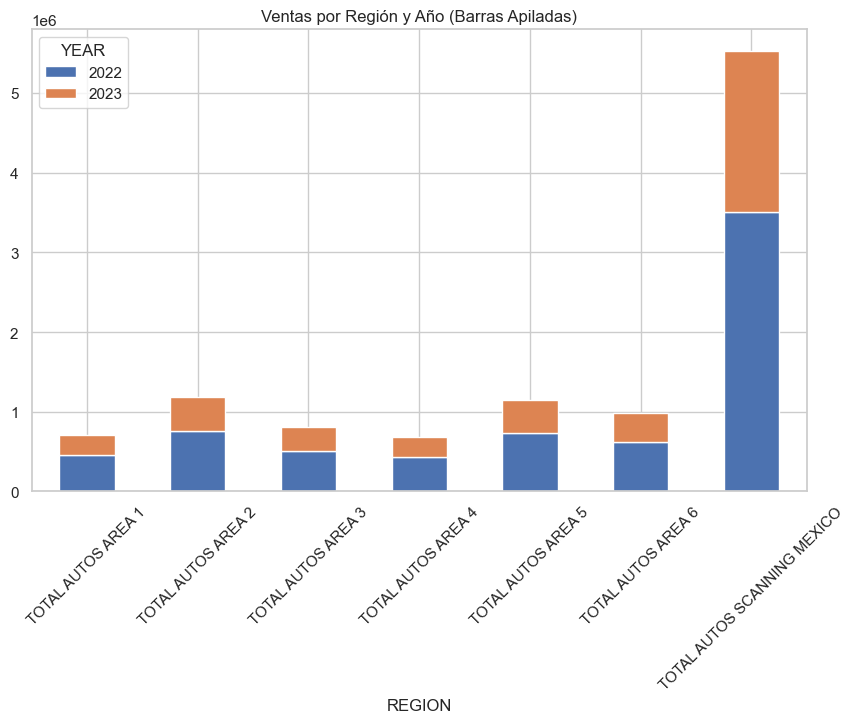

In [32]:
#Ventas por región
ventas_region = (
    df.groupby("REGION")["TOTAL_VALUE_SALES"]
    .sum()
    .sort_values(ascending=False)
)

display(ventas_region)

plt.figure()
sns.barplot(x=ventas_region.values, y=ventas_region.index)
plt.title("Ventas Totales por Región")
plt.show()

# Barras apiladas por región y año
if "YEAR" in df.columns:

    pivot_region_year = df.pivot_table(
        values="TOTAL_VALUE_SALES",
        index="REGION",
        columns="YEAR",
        aggfunc="sum"
    )

    display(pivot_region_year)

    pivot_region_year.plot(kind="bar", stacked=True, figsize=(10,6))
    plt.title("Ventas por Región y Año (Barras Apiladas)")
    plt.xticks(rotation=45)
    plt.show()

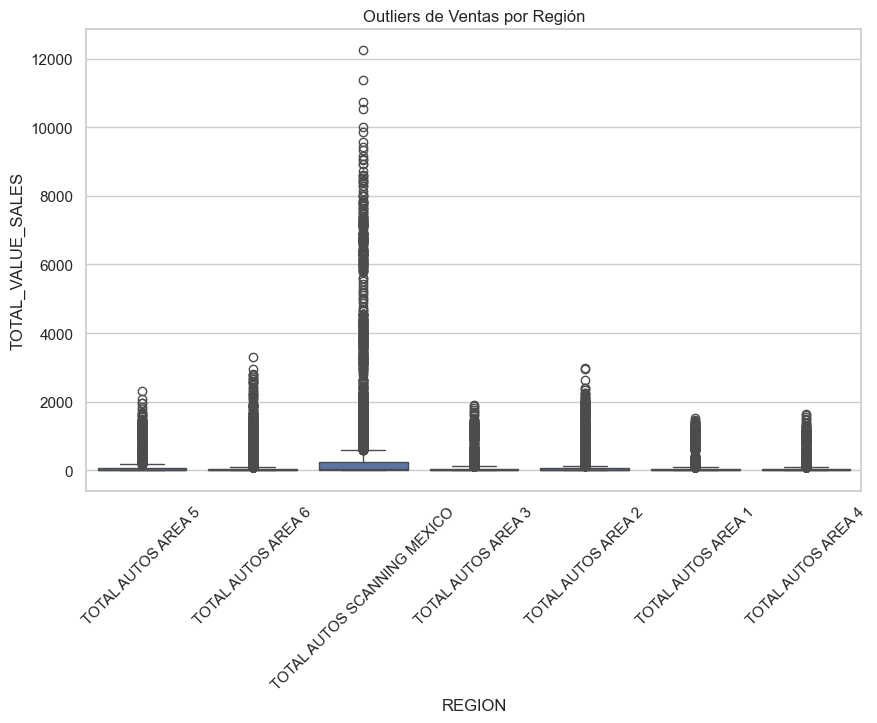

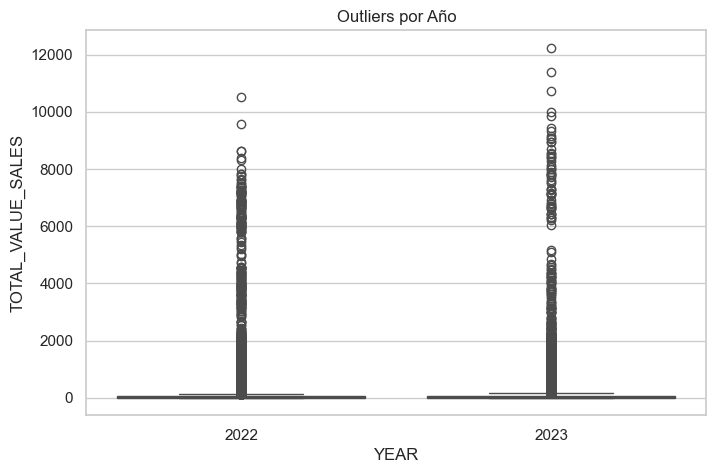

In [33]:
#Outliners
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="REGION",
    y="TOTAL_VALUE_SALES"
)
plt.xticks(rotation=45)
plt.title("Outliers de Ventas por Región")
plt.show()

if "YEAR" in df.columns:
    plt.figure()
    sns.boxplot(data=df, x="YEAR", y="TOTAL_VALUE_SALES")
    plt.title("Outliers por Año")
    plt.show()

In [40]:
#Insights
print("\n================ INSIGHTS PRINCIPALES ================")

print("\n1️. Distribución de Ventas:")
print("La distribución logarítmica de TOTAL_VALUE_SALES muestra una posible segmentación del negocio.")
print("Se observan dos concentraciones principales: ventas pequeñas recurrentes y ventas medianas-altas.")

print("\n2️. Concentración Región:")
print("La región 'TOTAL AUTOS SCANNING MEXICO' concentra significativamente mayor volumen de ventas en comparación con las demás regiones.")
print("Esto puede indicar una fuerte dependencia del negocio en un mercado principal.")

print("\n3️. Crecimiento Interanual:")
print("Al comparar 2022 vs 2023 se observa crecimiento transversal en todas las regiones.")
print("No se identifican regiones con decrecimiento, lo que sugiere expansión general del negocio.")

print("\n4️. Estacionalidad y Picos de Venta:")
print("Las tendencias por región muestran picos sincronizados en fechas similares.")
print("Esto podría estar asociado a campañas comerciales, cierres mensuales o estacionalidad compartida.")

print("\n5️. Riesgo Estratégico:")
print("La alta concentración de ingresos en una sola región representa fortaleza comercial,")
print("pero también puede implicar riesgo ante posibles cambios en ese mercado específico.")


================ INSIGHTS PRINCIPALES ================

1️. Distribución de Ventas:
La distribución logarítmica de TOTAL_VALUE_SALES muestra una posible segmentación del negocio.
Se observan dos concentraciones principales: ventas pequeñas recurrentes y ventas medianas-altas.

2️. Concentración Región:
La región 'TOTAL AUTOS SCANNING MEXICO' concentra significativamente mayor volumen de ventas en comparación con las demás regiones.
Esto puede indicar una fuerte dependencia del negocio en un mercado principal.

3️. Crecimiento Interanual:
Al comparar 2022 vs 2023 se observa crecimiento transversal en todas las regiones.
No se identifican regiones con decrecimiento, lo que sugiere expansión general del negocio.

4️. Estacionalidad y Picos de Venta:
Las tendencias por región muestran picos sincronizados en fechas similares.
Esto podría estar asociado a campañas comerciales, cierres mensuales o estacionalidad compartida.

5️. Riesgo Estratégico:
La alta concentración de ingresos en una so